# Constrained Optimization in jaxCAD

Constraints and gradient-based optimization address complementary aspects of a design problem: constraints define a feasible region, the optimizer finds the best design within it.

This notebook combines both: a distance constraint pins a sphere's center to a 2D manifold, and gradient descent with explicit projection finds the point on that manifold closest to a target.

In [23]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcad.constraints import ConstraintGraph, DistanceConstraint
from jaxcad.geometry import Vector
from jaxcad.render import render_marching_cubes
from jaxcad.sdf import Sphere, Translate

## Scene and constraint

The sphere's center `p` is free but constrained to remain at distance 2 from the origin. The target lies inside the constraint sphere - not on the manifold - so the optimal solution is the point on the sphere surface closest to the target.

In [24]:
anchor = Vector(jnp.array([0.0, 0.0, 0.0]), free=False, name="anchor")
p = Vector(jnp.array([2.0, 0.0, 0.0]), free=True, name="p")

graph = ConstraintGraph()
graph.add_constraint(DistanceConstraint(p, anchor, 2.0))

scene = Translate(Sphere(radius=0.3), offset=p)
target = jnp.array([1.0, 1.5, 0.0])

## Optimizing on the constraint manifold

At each step `build_constraint_jacobian` + `compute_null_space` re-evaluate the tangent directions at the current point, so the gradient step stays on the manifold as the point moves around the sphere.

In [ ]:
lr = 0.15
p_current = p.xyz
trajectory = [p_current]
gradients = []

for step in range(12):
    # Re-linearize: null space of constraint Jacobian at the current point
    param_vals = {
        cp.name: (p_current if cp.free else cp.xyz)
        for c in graph.constraints
        for cp in c.get_parameters()
    }
    J = graph.build_constraint_jacobian(param_vals, [p.name])
    null_space = graph.compute_null_space(J, p_current.shape[0])

    value, grad_r = jax.value_and_grad(
        lambda r, _p=p_current, _n=null_space: jnp.sum((_p + _n @ r - target) ** 2)
    )(jnp.zeros(null_space.shape[1]))

    step_dir = null_space @ grad_r
    gradients.append(step_dir)
    p_current = p_current - lr * step_dir
    trajectory.append(p_current)
    print(f"step {step:2d}  loss={value:.4f}  ||p||={jnp.linalg.norm(p_current):.4f}")

In [26]:
optimized = p_current
print(f"Optimized center:     {optimized}")
print(f"Distance from anchor: {jnp.linalg.norm(optimized):.6f}  (should be 2.0)")
print(f"Distance from target: {jnp.linalg.norm(optimized - target):.6f}")

# Analytic optimum: closest point on sphere to target
p_star = 2.0 * target / jnp.linalg.norm(target)
print(f"Analytic optimum:     {p_star}")

Optimized center:     [1.2402838 1.7364253 0.       ]
Distance from anchor: 2.133888  (should be 2.0)
Distance from target: 0.337095
Analytic optimum:     [1.1094004 1.6641006 0.       ]


## Trajectory

The trajectory stays on the circle (constraint manifold projected to the XY plane) and converges to the closest point to the target.

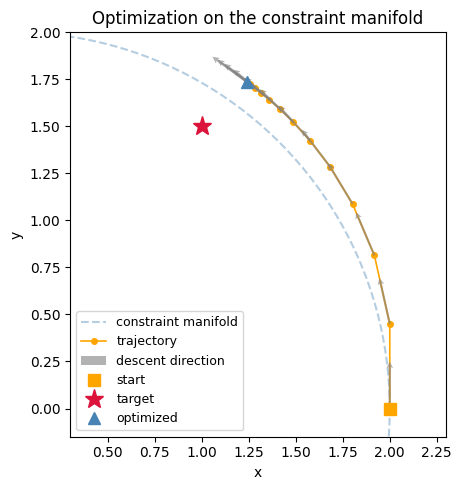

In [27]:
traj = np.array(trajectory)
grads = np.array(gradients)

theta = np.linspace(0, 2 * np.pi, 200)
cx, cy = 2 * np.cos(theta), 2 * np.sin(theta)

# Normalize gradients to fixed arrow length for readability
arrow_len = 0.25
grad_norms = np.linalg.norm(grads[:, :2], axis=1, keepdims=True)
grad_unit = grads[:, :2] / (grad_norms + 1e-8)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(cx, cy, "--", color="steelblue", alpha=0.4, label="constraint manifold")
ax.plot(
    traj[:, 0], traj[:, 1], "o-", color="orange", markersize=4, linewidth=1.2, label="trajectory"
)
ax.quiver(
    traj[:-1, 0],
    traj[:-1, 1],
    -grad_unit[:, 0] * arrow_len,
    -grad_unit[:, 1] * arrow_len,
    scale_units="xy",
    scale=1,
    width=0.006,
    headwidth=3,
    headlength=3,
    headaxislength=2.5,
    color="gray",
    alpha=0.6,
    label="descent direction",
    zorder=3,
)
ax.plot(*traj[0, :2], "s", color="orange", markersize=9, zorder=5, label="start")
ax.plot(*target[:2], "*", color="crimson", markersize=14, zorder=6, label="target")
ax.plot(*traj[-1, :2], "^", color="steelblue", markersize=9, zorder=5, label="optimized")
ax.set_xlim(0.3, 2.3)
ax.set_ylim(-0.15, 2.0)
ax.set_aspect("equal")
ax.legend(fontsize=9)
ax.set_title("Optimization on the constraint manifold")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## Render before and after

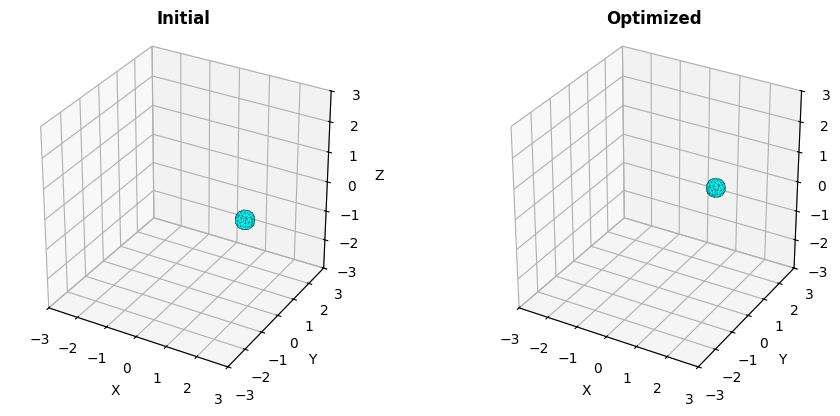

In [13]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(121, projection="3d")
render_marching_cubes(Translate(Sphere(radius=0.3), offset=traj[0]), ax=ax1, title="Initial")

ax2 = fig.add_subplot(122, projection="3d")
render_marching_cubes(Translate(Sphere(radius=0.3), offset=optimized), ax=ax2, title="Optimized")

plt.tight_layout()
plt.show()

## Summary

1. **Build the constraint graph** — `ConstraintGraph` + `add_constraint` attaches the distance constraint.
2. **Re-linearize at each step** — `build_constraint_jacobian` evaluates the constraint Jacobian at the current point; `compute_null_space` gives the tangent directions there.
3. **Step in the null space** — `obj(r) = obj(p + N @ r)` restricts the gradient to directions that keep the constraint satisfied, so no separate projection is needed.